In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering

from luwiji.cluster import demo

### Sample Data

In [2]:
X1, y1 = demo.blob_data()
X2, y2 = demo.moon_data()
X3, y3 = demo.circle_data()

### Visualize Data

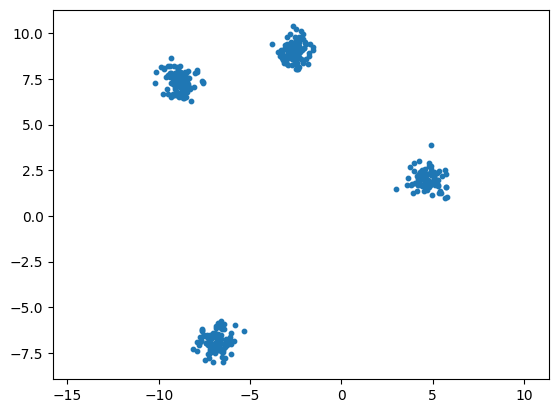

In [3]:
X = X1
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.axis("equal");

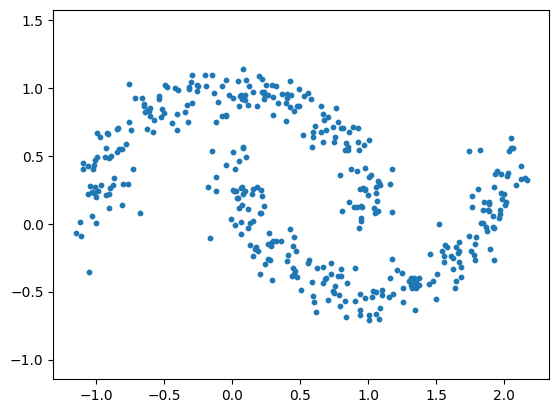

In [4]:
X = X2
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.axis("equal");

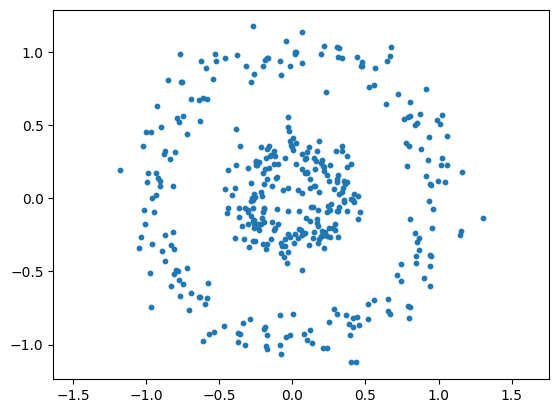

In [5]:
X = X3
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.axis("equal");

### K-Means Clustering

Nilai Kmeans : KMeans(n_clusters=4)

Member : [3 1 3 2 2 1 1 3 1 2 3 2 3 2 0 0 0 1 2 0 2 3 1 2 1 3 0 1 0 3 3 2 3 3 1 0 2
 2 1 0 1 3 3 0 2 2 1 0 1 2 1 3 0 2 2 3 2 1 3 2 0 2 3 0 1 1 0 0 0 3 1 0 3 2
 3 1 3 0 1 1 0 1 3 3 0 2 3 0 1 0 2 1 3 0 2 3 3 0 0 1 0 2 1 0 0 0 2 0 2 1 1
 3 2 2 3 3 3 2 3 1 0 2 3 1 3 0 0 2 0 1 1 1 0 3 0 3 1 0 1 0 1 0 0 2 1 3 0 1
 3 2 3 1 0 2 0 1 2 1 2 1 2 1 2 3 2 3 0 3 3 3 3 1 0 0 0 2 2 1 2 3 0 2 2 2 0
 2 1 1 0 0 2 3 3 2 0 0 3 0 3 3 2 1 0 1 1 2 3 1 3 0 1 2 2 1 2 0 0 2 1 2 0 1
 1 2 0 1 0 1 0 1 0 1 2 3 3 0 3 3 2 0 1 1 3 1 0 0 2 1 2 2 2 2 1 0 2 0 1 2 3
 3 1 2 2 3 3 0 0 0 1 2 2 0 0 2 1 0 1 1 2 3 1 2 0 3 1 1 3 3 3 2 2 3 2 2 0 3
 1 1 2 3 3 2 3 0 2 3 2 3 3 1 1 1 3 0 1 1 0 1 0 0 0 0 3 3 2 0 3 1 2 1 1 0 1
 2 3 0 3 1 1 3 3 0 2 1 3 2 2 3 3 1 2 2 3 2 3 2 2 1 2 1 3 3 0 0 3 0 2 0 0 3
 1 3 3 3 1 0 2 0 0 0 1 2 0 3 3 2 1 2 0 3 1 3 1 1 3 2 2 0 2 1]

Centre : [[-6.88174949 -6.93204687]
 [-2.57121515  9.02892796]
 [ 4.69349111  1.99188198]
 [-8.8837694   7.3527418 ]]

--- [Scatter Clusterin

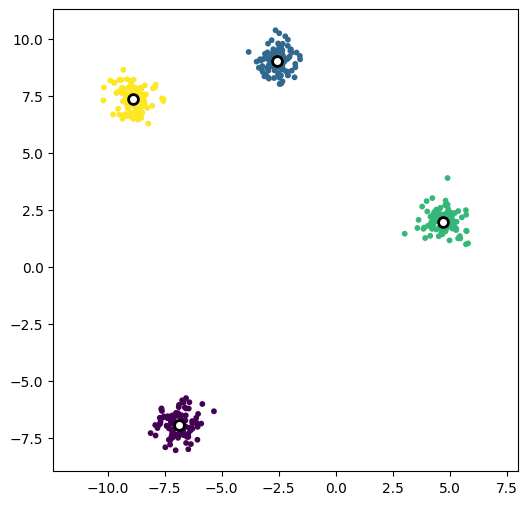

In [6]:
X = X1
kmeans = KMeans(n_clusters=4)
member = kmeans.fit_predict(X)
centre = kmeans.cluster_centers_

print(f"Nilai Kmeans : {kmeans}")
print(f"\nMember : {member}")
print(f"\nCentre : {centre}")

print("\n--- [Scatter Clustering] ---")
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10)
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

#### K-Means Weakness

- Kesulitan menentukan K  
--> Solusi : Elbow Analysis, Silhoutte Score, etc
- Hanya untuk data yang bisa diratakan  
--> Solusi : K-modes, K-medoid
- Solusi tidak selalu optimal
- Hanya untuk data yang "linearly-separable"


### CONTOH DATASET : MOON DATASET (GAGAL DALAM K-MEANS)

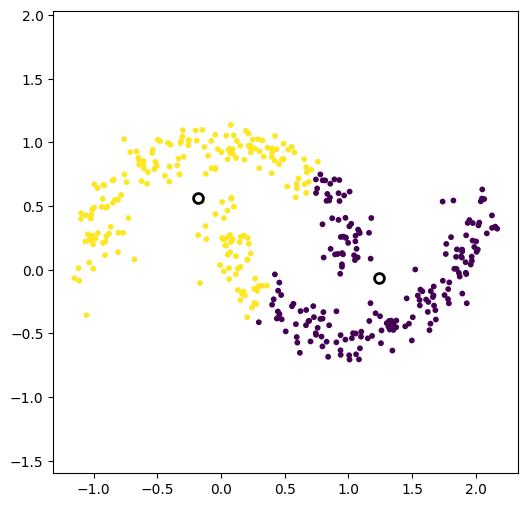

In [7]:
X = X2
kmeans = KMeans(n_clusters=2)
member = kmeans.fit_predict(X)
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10)
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

--> hasilnya tidak sesuai yang diharapkan, karena centroid tidak membentuk sabit secara utuh  
--> Tidak disarankan menggunakan K-means

### CONTOH DATASET : DONUT DATASET (GAGAL DALAM K-MEANS)

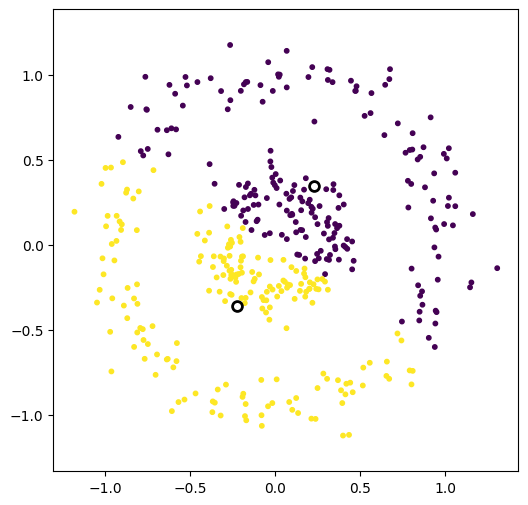

In [8]:
X = X3
kmeans = KMeans(n_clusters=2)
member = kmeans.fit_predict(X)
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10)
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

--> hasilnya tidak sesuai yang diharapkan, karena centroid tidak membentuk 1 lingkaran secara utuh (bagian dalam dan luar menjadi 2 cluster)

### Menentukan K (n_cluster) tanpa label -> Inertia / Elbow Analysis

Text(0.5, 0, 'n_clusters')

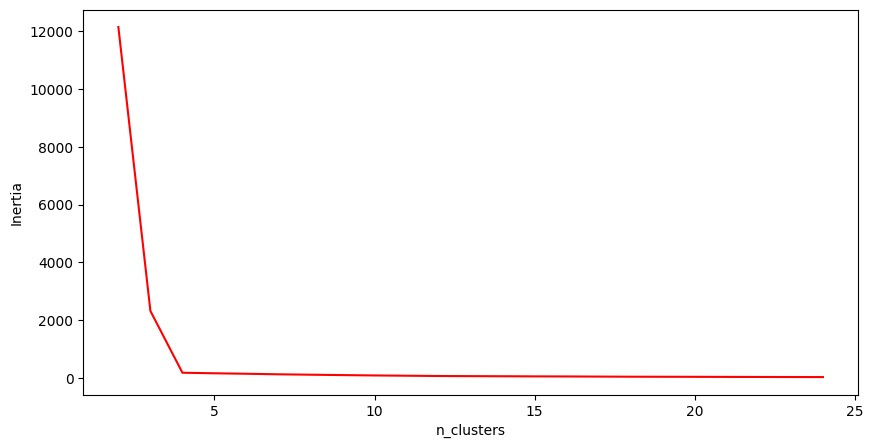

In [9]:
X = X1
score = []
for k in range(2,25):
  kmeans = KMeans(n_clusters=k)
  member = kmeans.fit_predict(X)
  score.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(2,25), score, "r-")
plt.ylabel("Inertia")
plt.xlabel("n_clusters")

Insight : Titik Elbow yang tajam (4) merupakan jumlah cluster K yang optimal yang dapat digunakan

### Menentukan K (n_cluster) label / Silhouette Score

In [10]:
from sklearn.metrics import silhouette_score

Text(0.5, 0, 'n_clusters')

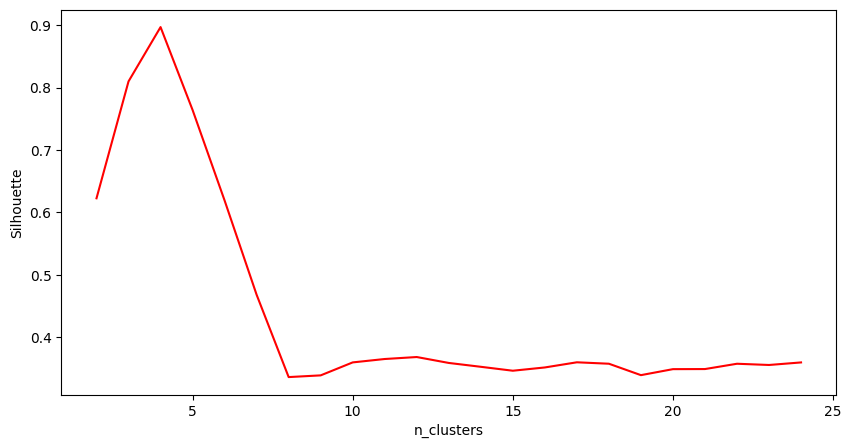

In [11]:
X = X1
score = []
for k in range(2,25):
  kmeans = KMeans(n_clusters=k)
  member = kmeans.fit_predict(X)
  
  siluet = silhouette_score(X, member, metric='euclidean')
  score.append(siluet)

plt.figure(figsize=(10,5))
plt.plot(range(2,25), score, "r-")
plt.ylabel("Silhouette")
plt.xlabel("n_clusters")

Insight : Kita tetap memakai K optimal yaitu 4, akan tetapi Silhouette Score digunakan pada saat ada "label" saja, sehingga tidak disarankan untuk menggunakan ini ketika tidak ada label

### BEYOND K-MEANS (Tidak Menggunakan K-Means)

#### Menggunakan Spectral Clustering untuk dataset seperti spiral, lingkaran, sabit

Labels : [1 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0 1 0 0
 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 0
 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 0 0 0 1 1 0
 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 0 0 1 0 0
 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 0 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0
 1 0 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 0 1 0 1 1 0 1 0 1 0 1 0 0 1
 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1
 0 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0
 1 1 0 0 0 0 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0
 1 1 1 0 1 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0]



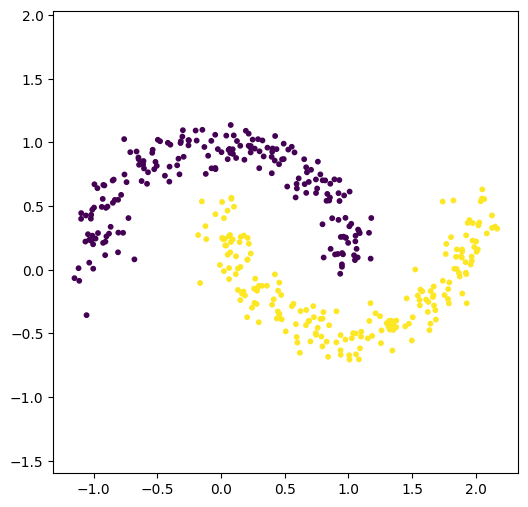

In [25]:
X = X2
sc = SpectralClustering(n_clusters=2, gamma=100)
labels = sc.fit_predict(X)

print(f"Labels : {labels}\n")

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.axis("equal");

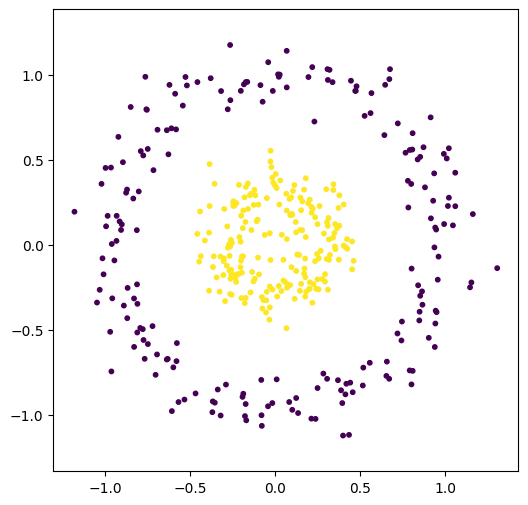

In [13]:
X = X3
sc = SpectralClustering(n_clusters=2, gamma=100)
labels = sc.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.axis("equal");

Insight : Terciptanya 2 cluster yang telah kita inginkan, sehingga lingkaran dalam dan luar sudah sepenuhnya utuh menjadi 1 cluster

Kesimpulan : Mencari titik yang terdekat sehingga dapat menciptakan pendekatan seperti cincin dalam dan luar

### DBSCAN (Density-Based Spatial Clustering of Applications)

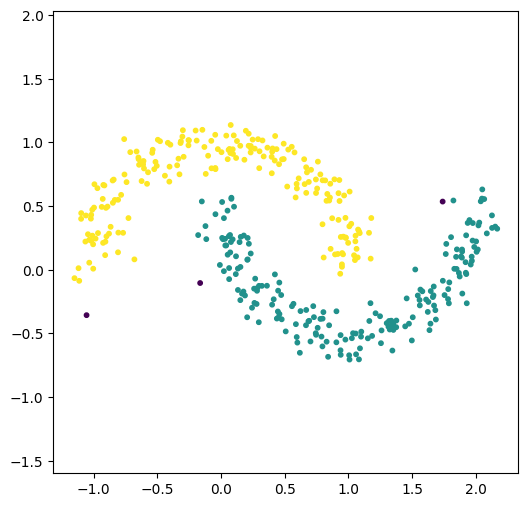

In [14]:
X = X2
dbscan = DBSCAN(eps=0.2)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.axis("equal");

Insight : Terdapat 3 cluster dengan warna yang berbeda, berwarna ungu tidak bergabung dengan warna kuning ataupun hijau muda karena penyebaran nya tidak sampai (layaknya seperti penyebaran virus)

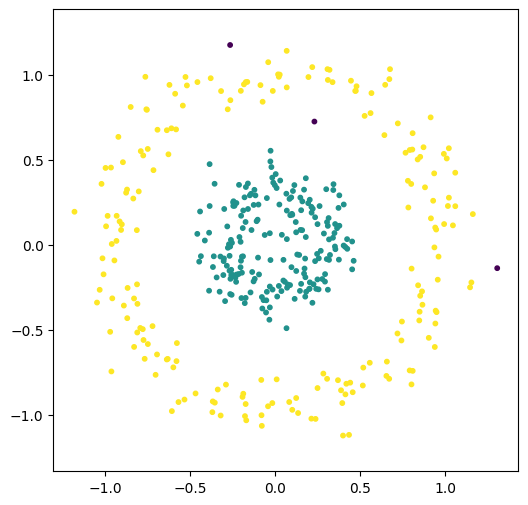

In [15]:
X = X3
dbscan = DBSCAN(eps=0.2)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.axis("equal");

### AHC (Agglomerative Hierarchical Clustering)

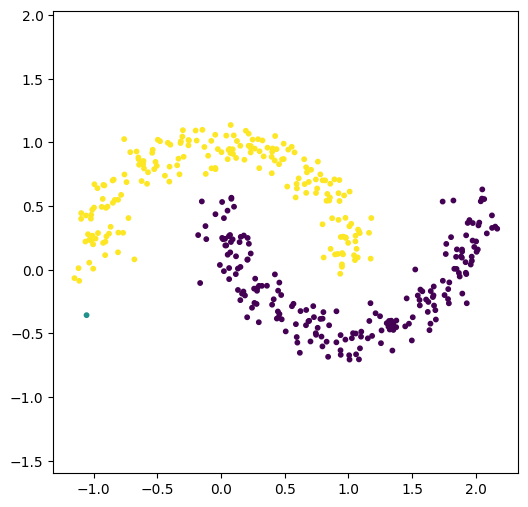

In [16]:
X = X2
ahc = AgglomerativeClustering(n_clusters=3, linkage='single')
labels = ahc.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.axis("equal");

Insight : Kuncinya terdapat pada linkage single, sehingga mencari titik terdekat kemudian membuat garis hingga menjadi hierarki tersendiri

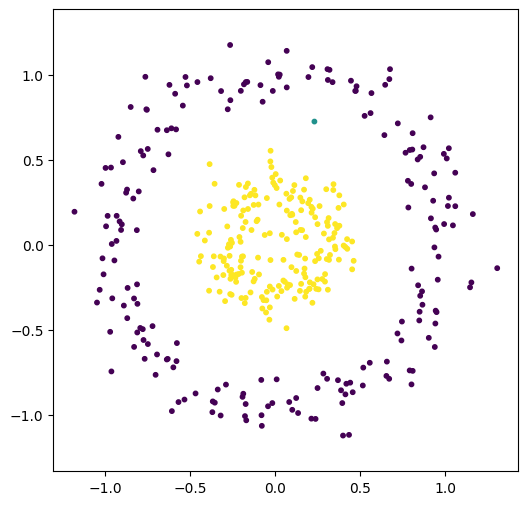

In [17]:
X = X3
ahc = AgglomerativeClustering(n_clusters=3, linkage='single')
labels = ahc.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.axis("equal");

### MENGGUNAKAN LIBRARY SPICY

In [18]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

In [19]:
X, y = demo.blob_data(30)

In [20]:
Z = linkage(X)

#### Mendapatkan membership

In [22]:
labels = fcluster(Z, 4, criterion="maxclust")
labels

array([4, 1, 2, 2, 4, 4, 1, 1, 4, 1, 1, 1, 2, 2, 2, 1, 3, 2, 4, 3, 3, 3,
       3, 2, 2, 4, 3, 4, 4, 3], dtype=int32)

In [26]:
labels = fcluster(Z, 5, criterion="maxclust")
labels

array([5, 1, 2, 2, 4, 5, 1, 1, 5, 1, 1, 1, 2, 2, 2, 1, 3, 2, 5, 3, 3, 3,
       3, 2, 2, 5, 3, 4, 5, 3], dtype=int32)

### Visualize Dendrogram

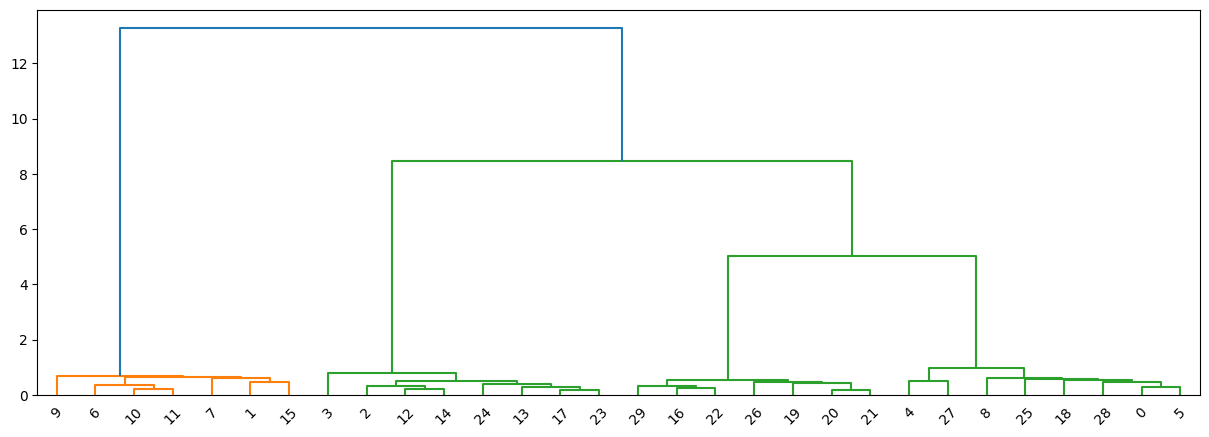

In [27]:
plt.figure(figsize=(15,5))
dendrogram(Z);